C:\Users\mchen\AppData\Local\Temp\ipykernel_13296\741250875.py:6: DtypeWarning: Columns (0: LANE_CNT) have mixed types. Specify dtype option on import or set low_memory=False.
  crashes = pd.read_csv("Traffic_Crashes_-_Crashes_20260922.csv")


             crashes  departures
crashes     1.000000    0.166811
departures  0.166811    1.000000


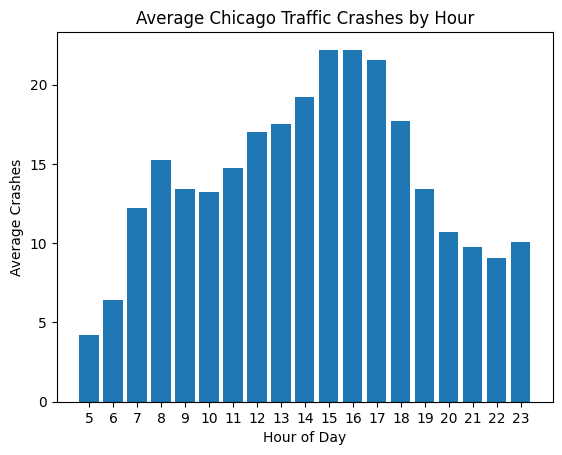

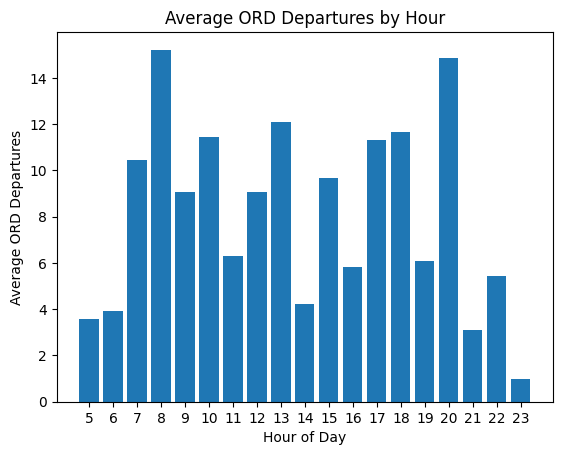

                 crashes  departures
period                              
Pre-pandemic   12.430267    7.513807
Pandemic       11.594493    4.452955
Post-pandemic  12.644493    5.750995


In [3]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

# Open csvs
crashes = pd.read_csv("Traffic_Crashes_-_Crashes_20260922.csv")
flights = pd.read_csv("airline.csv")

#print(crashes.columns)
#print(flights.columns)


# Clean crashes data
crashes["CRASH_DATE"] = pd.to_datetime(
    crashes["CRASH_DATE"],
    format="mixed"
)

# Extract date and hour for later use
crashes["date"] = crashes["CRASH_DATE"].dt.date
crashes["hour"] = crashes["CRASH_HOUR"]


# Clean flights data
flights["Date (MM/DD/YYYY)"] = pd.to_datetime(
    flights["Date (MM/DD/YYYY)"]
)

flights["date"] = flights["Date (MM/DD/YYYY)"].dt.date

flights["hour"] = pd.to_numeric(
    flights["Scheduled departure time"].astype(str).str[:2],
    errors="coerce"
)


# Group by hourly (for merging)
crash_hourly = (
    crashes
    .groupby(["date", "hour"])
    .size()
    .reset_index(name="crashes")
)

flight_hourly = (
    flights
    .groupby(["date", "hour"])
    .size()
    .reset_index(name="departures")
)

#print(crashes[["date", "hour"]].head())
#print(flights[["date", "hour"]].head())


# Merge both hourly sets together

integrated = pd.merge(
    crash_hourly,
    flight_hourly,
    on=["date", "hour"],
    how="inner"
)

# Print correlation
print(integrated[["crashes", "departures"]].corr())

# Get hourly pattern of crashes and compare charts (for question 1)
hourly_pattern = (
    integrated
    .groupby("hour")[["crashes", "departures"]]
    .mean()
    .reset_index()
)

#print(hourly_pattern)

plt.bar(hourly_pattern["hour"], hourly_pattern["crashes"])
plt.xlabel("Hour of Day")
plt.ylabel("Average Crashes")
plt.title("Average Chicago Traffic Crashes by Hour")
plt.xticks(range(5, 24))
plt.show()

plt.bar(hourly_pattern["hour"], hourly_pattern["departures"])
plt.xlabel("Hour of Day")
plt.ylabel("Average ORD Departures")
plt.title("Average ORD Departures by Hour")
plt.xticks(range(5, 24))
plt.show()

# Create integrated dataset for pandemic analysis
integrated_pandemic = pd.merge(
    crash_hourly,
    flight_hourly,
    on=["date", "hour"],
    how="outer"
)

# Replace missing values with 0
integrated_pandemic[["crashes", "departures"]] = (
    integrated_pandemic[["crashes", "departures"]].fillna(0)
)

# Add period column
integrated_pandemic["year"] = pd.to_datetime(
    integrated_pandemic["date"]
).dt.year

integrated_pandemic["period"] = pd.cut(
    integrated_pandemic["year"],
    bins=[2016, 2019, 2021, 2023],
    labels=["Pre-pandemic", "Pandemic", "Post-pandemic"]
)

# Summary via actual averages by period
period_summary = (
    integrated_pandemic
    .groupby("period", observed=True)[["crashes", "departures"]]
    .mean()
)

print(period_summary)

